In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('pyspark') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyspark', 'pyarrow'], check=True)
import pyspark; print('pyspark', pyspark.__version__)

pyspark 4.0.4


In [2]:
# ===== Self-contained setup: rebuilds the data this notebook needs in a fresh Colab session =====
import os, math, time, requests
from pathlib import Path
from pyspark.sql import SparkSession, functions as F

YEAR, MONTHS = 2024, [1, 2, 3]
BASE = Path('..') if Path('../data').exists() else Path('.')
RAW, LAKE = BASE / 'data' / 'raw', BASE / 'data' / 'lake'
for _p in (RAW, LAKE, BASE / 'results', BASE / 'models'):
    _p.mkdir(parents=True, exist_ok=True)
URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{y}-{m:02d}.parquet'
ZONES_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

def get_spark(name='nyc-taxi'):
    return (SparkSession.builder.appName(name).master('local[*]')
            .config('spark.driver.memory', '4g').config('spark.sql.shuffle.partitions', '16').getOrCreate())

def _download(url, dest):
    if dest.exists():
        return
    r = requests.get(url, stream=True, timeout=120); r.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            f.write(chunk)
    print('downloaded', dest.name, round(dest.stat().st_size / 1e6, 1), 'MB')

def ensure_raw_zone():
    """Download TLC files and write the partitioned Parquet raw zone (same as Stage 1)."""
    if (LAKE / 'raw_zone' / 'yellow_trips').exists() and (LAKE / 'raw_zone' / 'taxi_zones').exists():
        print('raw zone ready'); return
    spark = get_spark(); files = []
    for m in MONTHS:
        dest = RAW / f'yellow_tripdata_{YEAR}-{m:02d}.parquet'
        _download(URL.format(y=YEAR, m=m), dest); files.append(str(dest))
    _download(ZONES_URL, RAW / 'taxi_zone_lookup.csv')
    df = spark.read.parquet(*files).withColumn('pickup_month', F.date_format('tpep_pickup_datetime', 'yyyy-MM'))
    df.write.mode('overwrite').partitionBy('pickup_month').parquet(str(LAKE / 'raw_zone' / 'yellow_trips'))
    zones = spark.read.csv(str(RAW / 'taxi_zone_lookup.csv'), header=True, inferSchema=True)
    zones.write.mode('overwrite').parquet(str(LAKE / 'raw_zone' / 'taxi_zones'))
    print('raw zone written')

def ensure_curated_zone():
    """Clean, engineer features and split 70/15/15 (same rules as Stage 2)."""
    cz = LAKE / 'curated_zone'
    if (cz / 'test').exists():
        print('curated zone ready'); return
    ensure_raw_zone(); spark = get_spark()
    cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
            'RatecodeID', 'PULocationID', 'DOLocationID', 'fare_amount', 'pickup_month']
    df = spark.read.parquet(str(LAKE / 'raw_zone' / 'yellow_trips')).select(*cols).dropna().dropDuplicates()
    df = (df.withColumn('duration_min', (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60)
            .withColumn('speed_mph', F.col('trip_distance') / (F.col('duration_min') / 60)))
    valid_months = [f'{YEAR}-{m:02d}' for m in MONTHS]
    df = df.filter(F.col('pickup_month').isin(valid_months) & F.col('fare_amount').between(3, 200) &
                   F.col('trip_distance').between(0.1, 100) & F.col('passenger_count').between(1, 6) &
                   F.col('RatecodeID').between(1, 6) & F.col('PULocationID').between(1, 263) &
                   F.col('DOLocationID').between(1, 263) & F.col('duration_min').between(1, 180) &
                   (F.col('speed_mph') < 80))
    df = (df.withColumn('hour', F.hour('tpep_pickup_datetime'))
            .withColumn('dow', (F.dayofweek('tpep_pickup_datetime') + 5) % 7)
            .withColumn('is_weekend', (F.col('dow') >= 5).cast('int'))
            .withColumn('hour_sin', F.sin(2 * math.pi * F.col('hour') / 24))
            .withColumn('hour_cos', F.cos(2 * math.pi * F.col('hour') / 24)))
    for c in ['passenger_count', 'RatecodeID', 'PULocationID', 'DOLocationID']:
        df = df.withColumn(c, F.col(c).cast('int'))
    df = (df.withColumn('trip_distance', F.col('trip_distance').cast('double'))
            .withColumn('fare_amount', F.col('fare_amount').cast('double'))
            .select('trip_distance', 'passenger_count', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos',
                    'PULocationID', 'DOLocationID', 'RatecodeID', 'fare_amount', 'pickup_month'))
    df.write.mode('overwrite').parquet(str(cz / 'all'))      # materialise once -> reproducible split
    df = spark.read.parquet(str(cz / 'all')).withColumn('_r', F.rand(42))
    df.filter(F.col('_r') < 0.70).drop('_r').write.mode('overwrite').parquet(str(cz / 'train'))
    df.filter((F.col('_r') >= 0.70) & (F.col('_r') < 0.85)).drop('_r').write.mode('overwrite').parquet(str(cz / 'val'))
    df.filter(F.col('_r') >= 0.85).drop('_r').write.mode('overwrite').parquet(str(cz / 'test'))
    print('curated zone written')

def ensure_model_zone(frac=0.20):
    """Export the pandas-friendly sample used for neural-network training (same as Stage 3)."""
    mz, cz = LAKE / 'model_zone', LAKE / 'curated_zone'
    if (mz / 'test').exists():
        print('model zone ready'); return
    ensure_curated_zone(); spark = get_spark()
    for name in ['train', 'val', 'test']:
        s = spark.read.parquet(str(cz / name)).drop('pickup_month').sample(False, frac, seed=42)
        s.write.mode('overwrite').parquet(str(mz / name))
    print('model zone written')

ensure_curated_zone()

downloaded yellow_tripdata_2024-01.parquet 50.0 MB
downloaded yellow_tripdata_2024-02.parquet 50.3 MB
downloaded yellow_tripdata_2024-03.parquet 60.1 MB
downloaded taxi_zone_lookup.csv 0.0 MB
raw zone written
curated zone written


# Stage 3: Big Data Processing with PySpark
Architecture, distributed aggregations (Spark SQL), partition-pruning and scalability measurements, and the export of a modelling sample for the neural network.

## Architecture
```
TLC Parquet files --> [Ingestion: Stage 1] --> Data lake raw zone (Parquet, partitioned by month)
   --> [Spark cleaning + features: Stage 2] --> curated zone (train / val / test)
   --> [Spark SQL analytics + sampling: Stage 3] --> model zone (pandas-friendly Parquet)
   --> [Keras neural network: Stages 4-6] --> evaluation
```
The full dataset (millions of rows) stays in Spark. Only a configurable random sample is moved to memory for neural-network training, which is a standard approach when a single-machine GPU/CPU cannot hold everything.

In [3]:
from pathlib import Path
from pyspark.sql import SparkSession, functions as F

BASE = Path('..') if Path('../data').exists() else Path('.')
LAKE = BASE / 'data' / 'lake'
YEAR, MONTHS = 2024, [1, 2, 3]   # must match Stage 1

spark = (SparkSession.builder.appName('nyc-taxi-stage3').master('local[*]')
         .config('spark.driver.memory', '4g').config('spark.sql.shuffle.partitions', '16').getOrCreate())

cz = str(LAKE / 'curated_zone')
train = spark.read.parquet(cz + '/train')
val = spark.read.parquet(cz + '/val')
test = spark.read.parquet(cz + '/test')
train.createOrReplaceTempView('train')
zones = spark.read.parquet(str(LAKE / 'raw_zone' / 'taxi_zones'))
zones.createOrReplaceTempView('zones')
print('train rows:', train.count())

train rows: 5791911


## 1. Exploratory analytics with Spark SQL

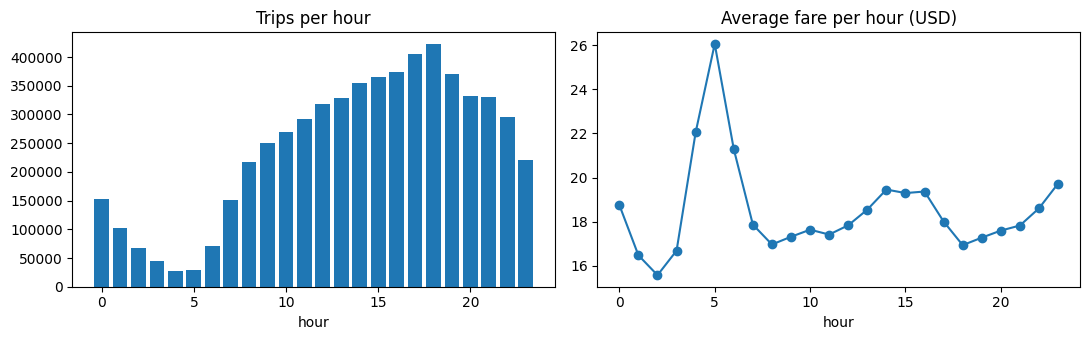

In [4]:
import matplotlib.pyplot as plt
by_hour = spark.sql('''
    SELECT hour, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM train GROUP BY hour ORDER BY hour''').toPandas()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(by_hour['hour'], by_hour['trips']); ax[0].set_title('Trips per hour'); ax[0].set_xlabel('hour')
ax[1].plot(by_hour['hour'], by_hour['avg_fare'], marker='o'); ax[1].set_title('Average fare per hour (USD)'); ax[1].set_xlabel('hour')
plt.tight_layout(); plt.savefig(str(BASE / 'results' / 'eda_hourly.png'), dpi=150); plt.show()

In [5]:
top_zones = spark.sql('''
    SELECT z.Zone, z.Borough, COUNT(*) AS trips, ROUND(AVG(t.fare_amount), 2) AS avg_fare
    FROM train t JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Zone, z.Borough ORDER BY trips DESC LIMIT 10''').toPandas()
top_zones

,Zone,Borough,trips,avg_fare
0,Midtown Center,Manhattan,290554,15.68
1,Upper East Side South,Manhattan,285705,12.53
2,JFK Airport,Queens,267947,61.94
3,Upper East Side North,Manhattan,265735,12.97
4,Midtown East,Manhattan,217634,15.29
5,Times Sq/Theatre District,Manhattan,208888,18.03
6,Penn Station/Madison Sq West,Manhattan,208763,16.35
7,Lincoln Square East,Manhattan,201216,13.60
8,LaGuardia Airport,Queens,188437,41.66
9,Midtown North,Manhattan,177320,15.46


In [6]:
dist_stats = train.select('trip_distance', 'fare_amount').summary().toPandas()
dist_stats

,summary,trip_distance,fare_amount
0,count,5791911,5791911
1,mean,3.196991868486818,18.161398614377134
2,stddev,4.169950669898147,15.783671243461082
3,min,0.1,3.0
4,25%,1.01,8.6
5,50%,1.7,12.8
6,75%,3.1,19.8
7,max,79.47,200.0


## 2. Scalability and partition pruning
Time the same aggregation on 1, 2 and 3 months of the raw zone, and compare a partition-pruned query with a full scan.
(Local mode on one machine: absolute numbers are small; report the trend and explain how a real cluster would scale.)

In [7]:
import time, pandas as pd
raw_zone = str(LAKE / 'raw_zone' / 'yellow_trips')
months = [f'{YEAR}-{m:02d}' for m in MONTHS]

def timed(fn, repeats=3):
    """Median wall-clock time of several runs (the first run in a session is slower: JVM warm-up, file listing, caching)."""
    ts = []
    for _ in range(repeats):
        t0 = time.time(); fn(); ts.append(time.time() - t0)
    return round(sorted(ts)[len(ts) // 2], 2)

def agg(subset):
    d = spark.read.parquet(raw_zone).filter(F.col('pickup_month').isin(subset))
    return d.groupBy('PULocationID').agg(F.avg('fare_amount'), F.count('*')).count()

agg(months)   # warm-up run, result discarded
rows = []
for k in range(1, len(months) + 1):
    n = spark.read.parquet(raw_zone).filter(F.col('pickup_month').isin(months[:k])).count()
    rows.append({'months': k, 'rows': n, 'median_seconds': timed(lambda: agg(months[:k]))})
scal = pd.DataFrame(rows)
scal.to_csv(str(BASE / 'results' / 'spark_scalability.csv'), index=False)
scal

,months,rows,median_seconds
0,1,2964617,0.50
1,2,5972150,0.54
2,3,9554757,0.70


In [8]:
lake = spark.read.parquet(raw_zone)
t_prune = timed(lambda: lake.filter(F.col('pickup_month') == months[0]).agg(F.avg('fare_amount')).collect())
t_full = timed(lambda: lake.filter(F.col('tpep_pickup_datetime') < f'{YEAR}-02-01').agg(F.avg('fare_amount')).collect())
print(f'partition-pruned: {t_prune:.2f}s | filter on non-partition column: {t_full:.2f}s (median of 3 runs)')

partition-pruned: 0.44s | filter on non-partition column: 0.65s (median of 3 runs)


## 3. Export modelling sample (model zone)
Random fractions of each split are converted to pandas-friendly Parquet. Increase `FRAC` if your machine has enough RAM.

In [9]:
FRAC = {'train': 0.20, 'val': 0.20, 'test': 0.20}
mz = LAKE / 'model_zone'
for name, d in [('train', train), ('val', val), ('test', test)]:
    s = d.drop('pickup_month').sample(False, FRAC[name], seed=42)
    s.write.mode('overwrite').parquet(str(mz / name))
    print(name, 'sample rows:', spark.read.parquet(str(mz / name)).count())

train sample rows: 1159653
val sample rows: 248560
test sample rows: 248510


## Notes for the report
- Describe the architecture diagram, the zones (raw / curated / model) and why Parquet + Spark were chosen.
- Include the scalability table and the pruning comparison, and state their limits (single machine).
- Next: Stage 4, baseline models.

In [10]:
spark.stop()  # free memory before training the neural network

In [11]:
# Optional: download this stage's results (tables/figures) because the Colab session is temporary
try:
    import shutil
    from google.colab import files
    shutil.make_archive('/content/results_stage3', 'zip', str(BASE / 'results'))
    files.download('/content/results_stage3.zip')
except Exception as e:
    print('download skipped:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>